# **Task 1: Data Loading**

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("/content/online_retail_sales - online_retail_sales.csv")

In [10]:
df.head(10)

,order_id,customer_id,country,product_category,unit_price,quantity,discount,order_date,delivery_days
0,10001,2102,UK,Toys,92.35,7,25,2023-08-27,7
1,10002,2435,Netherlands,Books,118.63,1,10,2023-11-20,12
2,10003,2270,UK,Clothing,108.65,3,15,2023-10-23,12
3,10004,2106,Italy,Books,79.94,5,15,2023-07-06,12
4,10005,2071,UK,Toys,41.12,5,10,2023-07-27,11
5,10006,2020,Spain,Toys,34.25,6,20,2023-08-08,1
6,10007,2121,Spain,Home,99.21,1,30,2023-07-09,3
7,10008,2466,France,Clothing,106.18,1,10,2023-12-12,12
8,10009,2214,Germany,Toys,65.43,7,20,2023-10-11,11
9,10010,2330,Germany,Home,33.10,1,5,2023-12-18,4


In [4]:
dfc=df

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          800 non-null    int64  
 1   customer_id       800 non-null    int64  
 2   country           800 non-null    object 
 3   product_category  800 non-null    object 
 4   unit_price        800 non-null    float64
 5   quantity          800 non-null    int64  
 6   discount          800 non-null    int64  
 7   order_date        800 non-null    object 
 8   delivery_days     800 non-null    int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 56.4+ KB


In [6]:
df.describe()

,order_id,customer_id,unit_price,quantity,discount,delivery_days
count,800.0000,800.000000,800.000000,800.00000,800.000000,800.000000
mean,10400.5000,2285.735000,63.761162,3.92375,15.637500,7.355000
std,231.0844,173.367832,33.493583,2.02622,10.070147,4.053025
min,10001.0000,2000.000000,5.020000,1.00000,0.000000,1.000000
25%,10200.7500,2130.000000,34.502500,2.00000,5.000000,4.000000
50%,10400.5000,2276.000000,65.635000,4.00000,15.000000,7.000000
75%,10600.2500,2441.250000,92.675000,6.00000,25.000000,11.000000
max,10800.0000,2595.000000,119.970000,7.00000,30.000000,14.000000


In [8]:
df.shape

(800, 9)

In [9]:
df.isna().sum()

,0
order_id,0
customer_id,0
country,0
product_category,0
unit_price,0
quantity,0
discount,0
order_date,0
delivery_days,0


# **Task 2: Basic Data Cleaning**

In [11]:
df['order_id'].duplicated().sum()

np.int64(0)

In [12]:
df = df.drop_duplicates(subset='order_id')

In [13]:
df = df[(df['discount'] >= 0) & (df['discount'] <= 30)]

In [14]:
df = df[(df['quantity'] > 0) & (df['unit_price'] > 0)]

In [15]:
df[['unit_price', 'quantity', 'delivery_days']].describe()

,unit_price,quantity,delivery_days
count,800.000000,800.00000,800.000000
mean,63.761162,3.92375,7.355000
std,33.493583,2.02622,4.053025
min,5.020000,1.00000,1.000000
25%,34.502500,2.00000,4.000000
50%,65.635000,4.00000,7.000000
75%,92.675000,6.00000,11.000000
max,119.970000,7.00000,14.000000


# **Task 3: Descriptive Statistics**

In [17]:
df[['unit_price', 'quantity', 'delivery_days']].agg(['mean', 'median', 'std'])
df[['unit_price', 'quantity', 'delivery_days']].describe()

,unit_price,quantity,delivery_days
count,800.000000,800.00000,800.000000
mean,63.761162,3.92375,7.355000
std,33.493583,2.02622,4.053025
min,5.020000,1.00000,1.000000
25%,34.502500,2.00000,4.000000
50%,65.635000,4.00000,7.000000
75%,92.675000,6.00000,11.000000
max,119.970000,7.00000,14.000000


In [19]:
df['delivery_days'].min()

1

In [20]:
df['delivery_days'].max()

14

In [21]:
df.groupby('country')['unit_price'].mean()

,unit_price
country,
France,65.957438
Germany,58.455338
Italy,70.658506
Netherlands,64.769500
Spain,60.058119
UK,64.240288


In [22]:
df.groupby('product_category')['quantity'].sum()

,quantity
product_category,
Books,644
Clothing,625
Electronics,585
Home,565
Toys,720


# **Task 4: Data Visualization**

In [25]:
import matplotlib.pyplot as plt

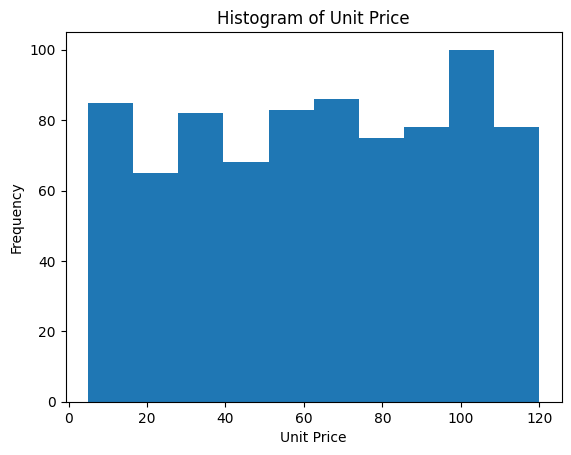

In [26]:
plt.figure()
plt.hist(df['unit_price'])
plt.title("Histogram of Unit Price")
plt.xlabel("Unit Price")
plt.ylabel("Frequency")
plt.show()

<Figure size 640x480 with 0 Axes>

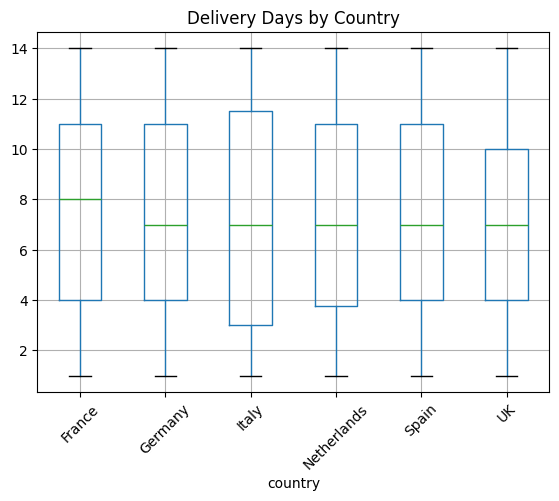

In [27]:
plt.figure()
df.boxplot(column='delivery_days', by='country', rot=45)
plt.title("Delivery Days by Country")
plt.suptitle("")
plt.show()

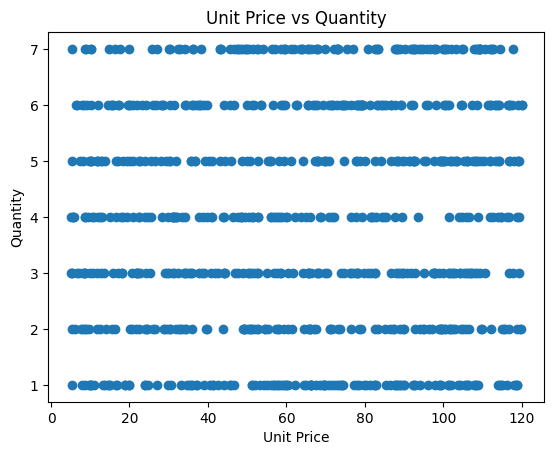

In [28]:
plt.figure()
plt.scatter(df['unit_price'], df['quantity'])
plt.xlabel("Unit Price")
plt.ylabel("Quantity")
plt.title("Unit Price vs Quantity")
plt.show()

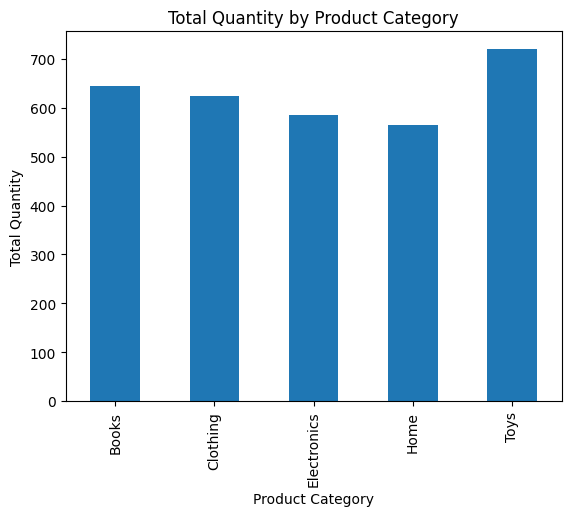

In [29]:
category_qty = df.groupby('product_category')['quantity'].sum()
plt.figure()
category_qty.plot(kind='bar')
plt.title("Total Quantity by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity")
plt.show()

# **Task 5: Feature Engineering**

In [30]:
df['total_revenue'] = df['unit_price'] * df['quantity'] * (1 - df['discount'] / 100)

In [31]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_month'] = df['order_date'].dt.month

In [32]:
df['fast_delivery'] = (df['delivery_days'] <= 5).astype(int)

In [33]:
df = pd.get_dummies(df, columns=['product_category'], drop_first=True)

# **Task 7: Train–Test Split**

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
y = df['total_revenue']
X = df.drop(columns=['total_revenue', 'order_id', 'customer_id', 'order_date'])

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Task 8: Regression Modeling**

In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
X_train = pd.get_dummies(X_train, columns=['country'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['country'], drop_first=True)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [40]:
y_pred = model.predict(X_test)

In [42]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae, mse, r2

(42.42290782543512, 3415.0404545723322, 0.8941708628088001)